# Notebook 03 - Bowler Matchup Analysis (Angle 2)

How does each batsman perform against each specific bowler they have faced enough times?

I filter to matchups with 20 or more balls faced and compute three metrics for each pair:
- Strike rate: how fast runs come off that bowler
- Boundary rate: what percentage of balls go for 4 or 6
- Dismissal probability: how often this bowler gets this batsman out per 100 balls

Balls faced is shown alongside every metric so you can judge how reliable each number is.

Season filter: 2021-2026. Matchup patterns shift as players adapt to each other, so older data is not that useful here.

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

## Step 1 - Load and Filter Data

Load deliveries.csv and apply the standard filters: 2021 onwards and no super overs. Super overs are tiebreaker balls played under completely different conditions so including them would distort regular match stats.

In [2]:
# load the pre-built ball-by-ball dataset
df = pd.read_csv('../data/processed/deliveries.csv')

# keep only 2021 onwards
df = df[df['season'] >= 2021]

# remove super over balls, not regular match deliveries
df = df[df['super_over'] == False]

n_rows = len(df)
seasons = sorted(df['season'].unique())
n_batsmen = df['batter'].nunique()
n_bowlers = df['bowler'].nunique()

print(f'Deliveries after filters: {n_rows:,}')
print(f'Seasons covered: {seasons}')
print(f'Unique batsmen: {n_batsmen}')
print(f'Unique bowlers: {n_bowlers}')

Deliveries after filters: 102,089
Seasons covered: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Unique batsmen: 366
Unique bowlers: 278


## Step 2 - Build the Matchup Table

For each batsman-bowler pair I compute:
- `balls_faced`: non-wide deliveries only, wides do not count as balls faced
- `runs_scored`: batter runs only, not extras
- `strike_rate`: runs per 100 balls
- `boundaries`: 4s and 6s hit by the batsman
- `boundary_rate`: boundaries as a percentage of balls faced
- `dismissals`: only wickets credited to the bowler (caught, bowled, lbw, stumped, hit wicket). Run outs are not included because the bowler did not earn them.
- `dismissal_prob`: dismissals per 100 balls

I then keep only matchups with 20 or more balls to avoid small sample noise.

In [3]:
# wides don't count as balls faced so remove them first
df_balls = df[df['is_wide'] == False].copy()

# a ball is a boundary if the batsman hit a 4 or 6
df_balls['is_boundary'] = df_balls['is_boundary_4'] | df_balls['is_boundary_6']

# only these dismissal types belong to the bowler
# run outs are not the bowler's doing
bowler_wicket_types = ['caught', 'bowled', 'lbw', 'stumped', 'hit wicket', 'caught and bowled']

df_balls['bowler_wicket'] = (
    df_balls['wicket'] &
    df_balls['wicket_kind'].isin(bowler_wicket_types)
)

# group by batsman and bowler and count everything up
matchups = df_balls.groupby(['batter', 'bowler']).agg(
    balls_faced=('batter_runs', 'count'),
    runs_scored=('batter_runs', 'sum'),
    boundaries=('is_boundary', 'sum'),
    dismissals=('bowler_wicket', 'sum')
).reset_index()

# compute the three metrics
matchups['strike_rate'] = (matchups['runs_scored'] / matchups['balls_faced'] * 100).round(1)
matchups['boundary_rate'] = (matchups['boundaries'] / matchups['balls_faced'] * 100).round(1)
matchups['dismissal_prob'] = (matchups['dismissals'] / matchups['balls_faced'] * 100).round(2)

# drop any matchup with fewer than 20 balls
matchups = matchups[matchups['balls_faced'] >= 20].reset_index(drop=True)

n_matchups = len(matchups)
print(f'Total matchups with 20+ balls: {n_matchups:,}')
print()
print('Top 10 matchups by balls faced:')
print(matchups.sort_values('balls_faced', ascending=False).head(10).to_string(index=False))

Total matchups with 20+ balls: 897

Top 10 matchups by balls faced:
      batter         bowler  balls_faced  runs_scored  boundaries  dismissals  strike_rate  boundary_rate  dismissal_prob
    KL Rahul Mohammed Siraj           84          126          22           2        150.0           26.2            2.38
     V Kohli  Harpreet Brar           72           79           8           2        109.7           11.1            2.78
     V Kohli    Rashid Khan           71           99           9           1        139.4           12.7            1.41
  RD Gaikwad    Rashid Khan           69          113          15           2        163.8           21.7            2.90
  RD Gaikwad Mohammed Shami           69           61           7           0         88.4           10.1            0.00
F du Plessis       TA Boult           66           80          13           2        121.2           19.7            3.03
Shubman Gill      RA Jadeja           64          106          14           1 

## Step 3 - Heatmaps

A heatmap lets you scan many matchups at once. The color shows immediately where a batsman dominates or struggles against a specific bowler.

I pick the top 20 batsmen and top 20 bowlers by total balls in the matchup table. Cells with fewer than 20 balls are left blank.

Strike rate heatmap: color centers at 130, roughly the IPL average in this era. Green is above average, red is below.

Dismissal probability heatmap: higher means the bowler gets this batsman out more often. Color scale is reversed so red still means bad for the batsman.

In [4]:
# take the 20 most frequently matched batsmen and bowlers by total balls
top_batsmen = (
    matchups.groupby('batter')['balls_faced'].sum()
    .nlargest(20).index.tolist()
)
top_bowlers = (
    matchups.groupby('bowler')['balls_faced'].sum()
    .nlargest(20).index.tolist()
)

heatmap_df = matchups[
    matchups['batter'].isin(top_batsmen) &
    matchups['bowler'].isin(top_bowlers)
].copy()

# pivot to a matrix, blank cells mean fewer than 20 balls faced
sr_matrix = heatmap_df.pivot_table(index='batter', columns='bowler', values='strike_rate')

# show the SR value inside each cell, blank if no data
text_vals = [
    [str(int(v)) if not pd.isna(v) else '' for v in row]
    for row in sr_matrix.values
]

fig = go.Figure(data=go.Heatmap(
    z=sr_matrix.values,
    x=sr_matrix.columns.tolist(),
    y=sr_matrix.index.tolist(),
    text=text_vals,
    texttemplate='%{text}',
    colorscale='RdYlGn',
    zmid=130,   # IPL average SR in this era, green means above average
    colorbar=dict(title='Strike Rate')
))

fig.update_layout(
    title='Strike Rate: Top 20 Batsmen vs Top 20 Bowlers (2021-2026)<br><sup>Blank cells = fewer than 20 balls faced | Center = 130 (IPL average)</sup>',
    xaxis_title='Bowler',
    yaxis_title='Batsman',
    width=1100,
    height=900,
    xaxis=dict(tickangle=-45)
)

fig.show()

In [5]:
# same structure as above but for dismissal probability
# color scale is reversed so high dismissal rate shows as red (bad for the batsman)

dp_matrix = heatmap_df.pivot_table(index='batter', columns='bowler', values='dismissal_prob')

dp_text = [
    ['{:.1f}'.format(v) if not pd.isna(v) else '' for v in row]
    for row in dp_matrix.values
]

fig2 = go.Figure(data=go.Heatmap(
    z=dp_matrix.values,
    x=dp_matrix.columns.tolist(),
    y=dp_matrix.index.tolist(),
    text=dp_text,
    texttemplate='%{text}',
    colorscale='RdYlGn_r',
    colorbar=dict(title='Dismissal % per ball')
))

fig2.update_layout(
    title='Dismissal Probability: Top 20 Batsmen vs Top 20 Bowlers (2021-2026)<br><sup>Higher = more likely to be dismissed per ball | Blank = fewer than 20 balls faced</sup>',
    xaxis_title='Bowler',
    yaxis_title='Batsman',
    width=1100,
    height=900,
    xaxis=dict(tickangle=-45)
)

fig2.show()

## Step 4 - Clustering Batsmen by Matchup Profile

The heatmap shows individual matchups. Now I zoom out and ask if there are natural groups of batsmen with similar profiles overall.

This is k-means clustering. The idea:
1. For each batsman, compute their average strike rate, boundary rate and dismissal probability across all their matchups
2. Each batsman is now a point in 3D space, one dimension per metric
3. K-means finds cluster centres that minimise the distance from each point to its nearest centre
4. Batsmen close to the same centre get the same label

I use StandardScaler before running k-means. Strike rate ranges from roughly 80 to 200 while dismissal probability ranges from 0 to 10. Without scaling, k-means would cluster almost entirely on strike rate and ignore the other two. StandardScaler transforms each feature to mean 0 and standard deviation 1 so all three contribute equally.

The elbow method helps pick the right number of clusters. I try k from 2 to 7, plot how much the inertia (total within-cluster distance) drops with each extra cluster, and pick the point where adding another cluster stops helping much.

In [6]:
# average out each batsman's stats across all their matchups
batsman_profile = matchups.groupby('batter').agg(
    avg_sr=('strike_rate', 'mean'),
    avg_boundary_rate=('boundary_rate', 'mean'),
    avg_dismissal_prob=('dismissal_prob', 'mean'),
    total_balls=('balls_faced', 'sum'),
    num_matchups=('bowler', 'count')
).reset_index()

# only include batsmen with 200 or more total balls and at least 5 different bowlers
# players with less data than this are not worth clustering on
batsman_profile = batsman_profile[
    (batsman_profile['total_balls'] >= 200) &
    (batsman_profile['num_matchups'] >= 5)
].reset_index(drop=True)

n_eligible = len(batsman_profile)
print(f'Batsmen eligible for clustering: {n_eligible}')
print()
print(batsman_profile[['avg_sr', 'avg_boundary_rate', 'avg_dismissal_prob']].describe().round(2))

Batsmen eligible for clustering: 38

       avg_sr  avg_boundary_rate  avg_dismissal_prob
count   38.00              38.00               38.00
mean   143.06              20.04                3.78
std     11.91               3.05                1.00
min    117.01              14.63                1.66
25%    135.85              18.09                2.95
50%    142.54              19.46                3.85
75%    147.27              21.16                4.40
max    172.13              27.95                5.88


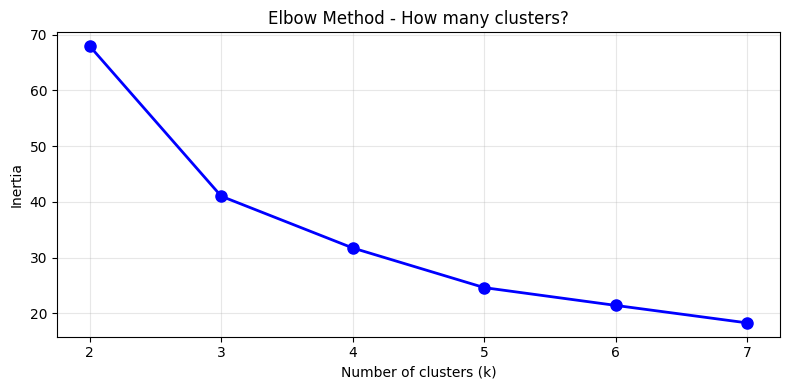

In [7]:
features = ['avg_sr', 'avg_boundary_rate', 'avg_dismissal_prob']
X = batsman_profile[features].values

# scale each feature to mean 0 and std 1 so strike rate doesn't dominate the clustering
# fit_transform learns the scale from X and applies it in one step
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# try k from 2 to 7 and plot inertia to see where adding another cluster stops helping
inertia = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - How many clusters?')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# fit with k=4, change this if the elbow plot pointed somewhere else
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
batsman_profile['cluster'] = km.fit_predict(X_scaled)

# undo the scaling to read cluster centres in the original units
centers = scaler.inverse_transform(km.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features)
centers_df.index.name = 'cluster'

print('Cluster centres (original scale):')
print(centers_df.round(1))
print()
print('Batsmen per cluster:')
print(batsman_profile['cluster'].value_counts().sort_index())

Cluster centres (original scale):
         avg_sr  avg_boundary_rate  avg_dismissal_prob
cluster                                               
0         148.5               20.4                 4.5
1         143.0               19.4                 2.7
2         162.6               26.4                 4.2
3         131.4               17.9                 4.3

Batsmen per cluster:


cluster
0     8
1    13
2     5
3    12
Name: count, dtype: int64


In [9]:
# scatter of SR vs boundary rate, coloured by cluster
# hover over any dot to see the player name and full stats
fig3 = px.scatter(
    batsman_profile,
    x='avg_sr',
    y='avg_boundary_rate',
    color=batsman_profile['cluster'].astype(str),
    hover_name='batter',
    hover_data={
        'avg_sr': ':.1f',
        'avg_boundary_rate': ':.1f',
        'avg_dismissal_prob': ':.2f',
        'total_balls': True
    },
    title='Batsman Clusters by Matchup Profile (2021-2026)',
    labels={
        'avg_sr': 'Avg Strike Rate',
        'avg_boundary_rate': 'Avg Boundary Rate (%)',
        'color': 'Cluster'
    }
)
fig3.update_traces(marker=dict(size=10))
fig3.update_layout(width=900, height=600)
fig3.show()

print()
print('Look at the cluster centres above and label each cluster yourself:')
print('e.g. Cluster 0 = aggressive hitters (high SR, high boundary rate)')
print('     Cluster 1 = accumulators (moderate SR, low boundary rate)')
print('     Cluster 2 = ...')


Look at the cluster centres above and label each cluster yourself:
e.g. Cluster 0 = aggressive hitters (high SR, high boundary rate)
     Cluster 1 = accumulators (moderate SR, low boundary rate)
     Cluster 2 = ...


In [10]:
# save both files for use in the Streamlit app later
matchups.to_csv('../data/processed/bowler_matchups.csv', index=False)
batsman_profile.to_csv('../data/processed/batsman_profiles.csv', index=False)

print('Saved:')
print(f'  bowler_matchups.csv  - {len(matchups):,} rows')
print(f'  batsman_profiles.csv - {len(batsman_profile):,} rows')

Saved:
  bowler_matchups.csv  - 897 rows
  batsman_profiles.csv - 38 rows


In [11]:
print(batsman_profile[batsman_profile['cluster'] == 3][['batter', 'avg_sr', 'avg_boundary_rate', 'avg_dismissal_prob', 'total_balls']].to_string(index=False))  

    batter     avg_sr  avg_boundary_rate  avg_dismissal_prob  total_balls
AK Markram 130.200000          15.023529            3.834706          479
D Padikkal 125.747368          18.326316            4.345263          549
 HH Pandya 122.100000          14.633333            3.742667          490
    N Rana 137.020000          19.306667            3.904667          450
 Q de Kock 135.675000          19.187500            4.223750          407
   R Parag 134.414286          17.607143            5.879286          409
RD Gaikwad 138.029032          18.793548            3.864839         1049
 RG Sharma 130.577273          19.631818            4.985455          683
   RR Pant 136.707143          18.578571            3.883571          423
    S Dube 134.592857          17.607143            3.472857          408
   VR Iyer 135.253333          18.080000            3.735333          415
   WP Saha 117.011111          17.977778            5.713333          249


## Key Findings

**Matchup table**: 897 bowler-batsman matchups qualified with 20 or more balls faced in 2021-2026. The most heavily matched pair is KL Rahul vs Mohammed Siraj at 84 balls, giving a reliable read on that specific contest.

**Clustering**: 38 batsmen had enough data (200+ total balls, 5+ distinct bowlers) to cluster on. Four groups emerged:

| Cluster | Label | Avg SR | Boundary % | Dismissal % | Players |
|---|---|---|---|---|---|
| 0 | High-risk hitters | 148.5 | 20.4 | 4.5 | 8 |
| 1 | Reliable anchors | 143.0 | 19.4 | 2.7 | 13 |
| 2 | Match-winners | 162.6 | 26.4 | 4.2 | 5 |
| 3 | Under-performing against bowlers | 131.4 | 17.9 | 4.3 | 12 |

Cluster 1 and 0 have similar strike rates but Cluster 1 batsmen get out at roughly half the rate. Same run output, much lower risk - that distinction matters in T20 cricket where wickets are finite.

**Cluster 2 - the standout group**: Five batsmen - Abhishek Sharma, Yashasvi Jaiswal, Travis Head, Mitchell Marsh, and Prabhsimran Singh - separated out with high SR and high boundary rates. Jaiswal's 822 balls is the largest sample in the group by far, spanning many more bowlers and matches. That is a consistent pattern, not a hot streak.

**Limitation**: clustering is on aggregate matchup stats (overall SR, boundary rate, dismissal prob) rather than pace vs spin breakdowns, since Cricsheet does not include bowler type. A manual bowler type mapping would allow a more granular vulnerability analysis.